In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
# Load Iris dataset
data = load_iris()
X = data.data       # Features
y = data.target     # Labels

In [3]:
# Scale the data (important for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

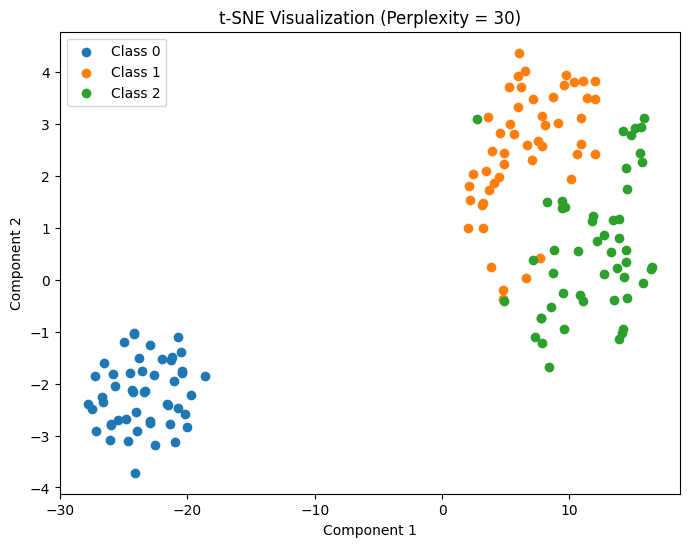

In [5]:
# Plot results
plt.figure(figsize=(8,6))

for i in range(3):
    plt.scatter(
        X_tsne[y == i, 0],
        X_tsne[y == i, 1],
        label=f"Class {i}"
    )

plt.legend()
plt.title("t-SNE Visualization (Perplexity = 30)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

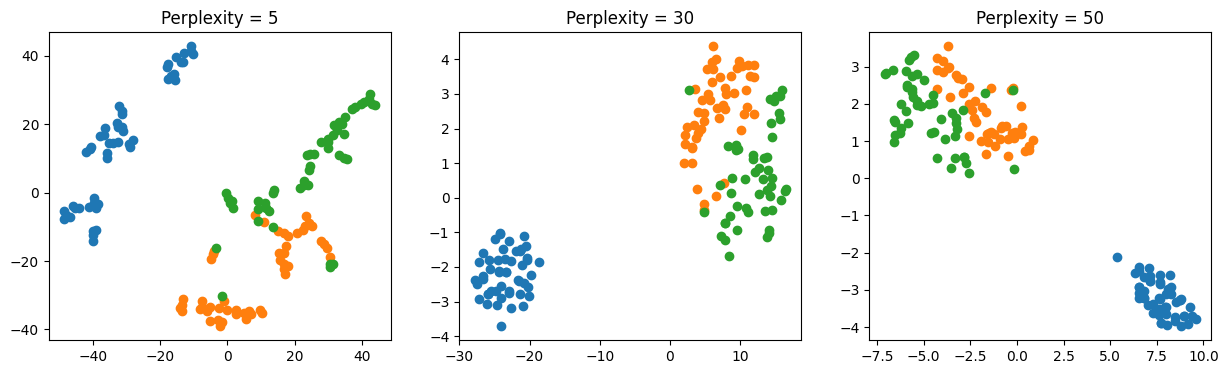

In [6]:
perplexities = [5, 30, 50]

plt.figure(figsize=(15,4))

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    
    for j in range(3):
        plt.scatter(
            X_tsne[y == j, 0],
            X_tsne[y == j, 1]
        )
    
    plt.title(f"Perplexity = {perp}")

plt.show()

7. Observations
Low perplexity → small tight clusters
Medium perplexity → balanced view
High perplexity → more global structure

- t-SNE is great for visualization
- It preserves local structure well
- Results depend on parameters
- Not suitable for training ML models